In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/52235.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/9273.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/18966.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/45170.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/4353.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/41461.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/49472.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/26801.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/32197.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/59254.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/41414.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/57325.png
/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training/7/18315.png
/kaggle/input/

In [2]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


In [3]:
import os

os.makedirs("/kaggle/working/models", exist_ok=True)
os.makedirs("/kaggle/working/outputs", exist_ok=True)

In [4]:
import os

train_dir = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"
test_dir = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing"

print("Training path:", train_dir)
print("Testing path:", test_dir)

Training path: /kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training
Testing path: /kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing


In [5]:
import cv2
import numpy as np

def load_images(folder):
    images = []
    labels = []

    for label in sorted(os.listdir(folder)):
        label_path = os.path.join(folder, label)

        if not os.path.isdir(label_path):
            continue

        for filename in os.listdir(label_path):
            img_path = os.path.join(label_path, filename)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = img.astype("float32") / 255.0

            images.append(img)
            labels.append(int(label))

    images = np.array(images)
    labels = np.array(labels)

    return images, labels

In [6]:
x_train, y_train = load_images(train_dir)
x_test, y_test = load_images(test_dir)

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


In [7]:
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

Train Shape: (60000, 28, 28, 1)
Test Shape: (10000, 28, 28, 1)


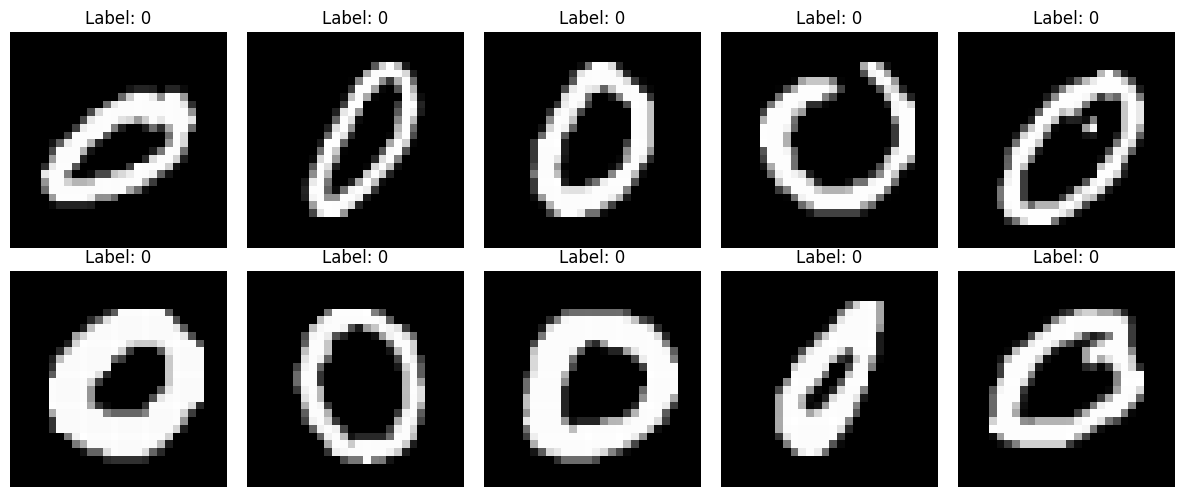

In [8]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Noise intensity
noise_factor = 0.5

# Generate noisy images
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy training shape:", x_train_noisy.shape)
print("Noisy testing shape :", x_test_noisy.shape)

Noisy training shape: (60000, 28, 28, 1)
Noisy testing shape : (10000, 28, 28, 1)


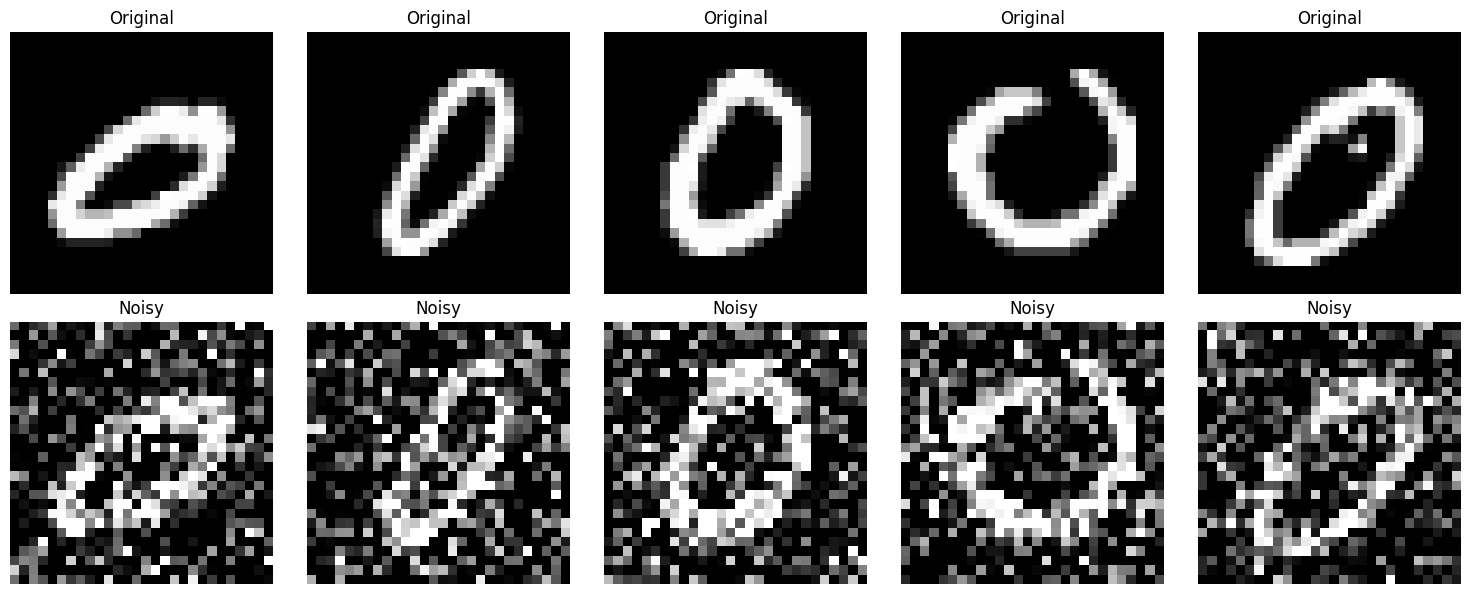

In [11]:
plt.figure(figsize=(15, 6))

for i in range(5):

    # Original Image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    plt.subplot(2, 5, i + 6)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

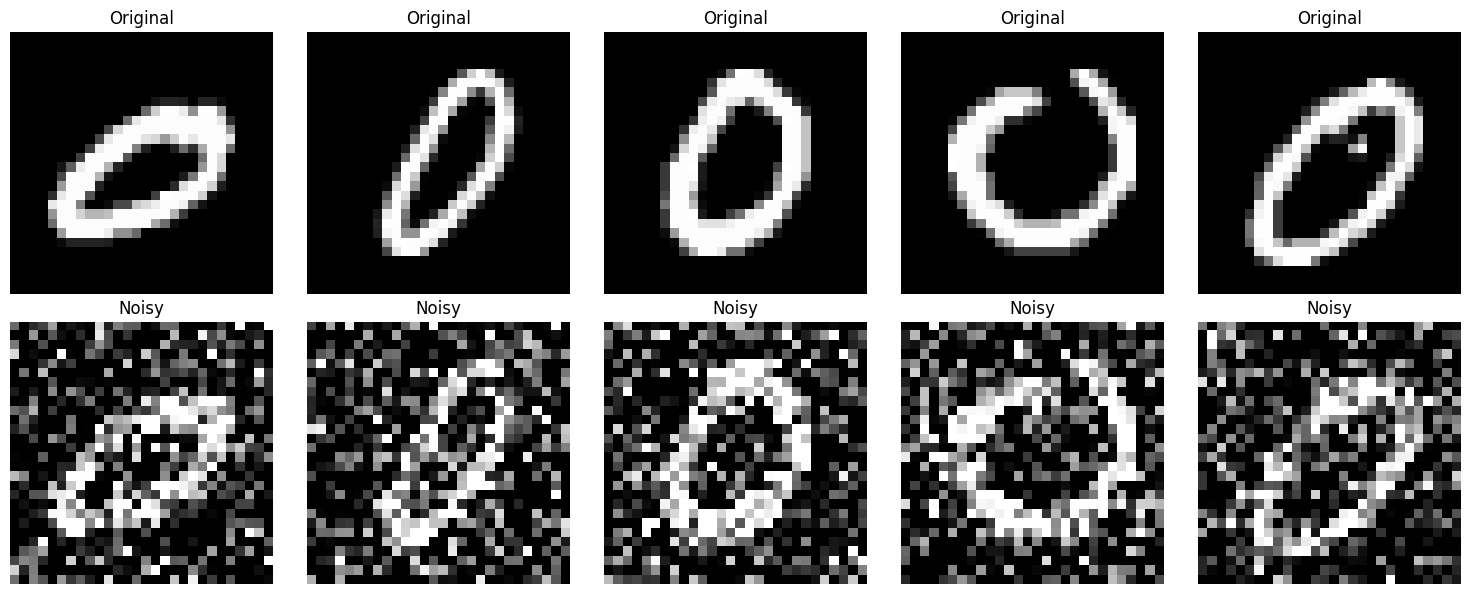

In [12]:
plt.figure(figsize=(15, 6))

for i in range(5):

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2, 5, i + 6)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis("off")
    plt.title("Noisy")

plt.tight_layout()

plt.savefig("/kaggle/working/outputs/original_vs_noisy.png")
plt.show()

In [13]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

from tensorflow.keras.models import Model

In [14]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(
    pool_size=(2,2),
    padding='same'
)(x)

x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(x)

encoded = MaxPooling2D(
    pool_size=(2,2),
    padding='same'
)(x)

I0000 00:00:1783237649.548235      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783237649.551256      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [16]:
x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    filters=1,
    kernel_size=(3,3),
    activation='sigmoid',
    padding='same'
)(x)

In [17]:
autoencoder = Model(inputs=input_img, outputs=decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="/kaggle/working/models/mnist_autoencoder.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [21]:
history = autoencoder.fit(
    x=x_train_noisy,
    y=x_train,

    epochs=20,
    batch_size=128,

    shuffle=True,

    validation_data=(x_test_noisy, x_test),

    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
 31/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7979 - loss: 0.5502

I0000 00:00:1783238333.720305     172 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8053 - loss: 0.2520
Epoch 1: val_loss improved from None to 0.11569, saving model to /kaggle/working/models/mnist_autoencoder.keras

Epoch 1: finished saving model to /kaggle/working/models/mnist_autoencoder.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8073 - loss: 0.1657 - val_accuracy: 0.8095 - val_loss: 0.1157
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8107 - loss: 0.1145
Epoch 2: val_loss improved from 0.11569 to 0.10819, saving model to /kaggle/working/models/mnist_autoencoder.keras

Epoch 2: finished saving model to /kaggle/working/models/mnist_autoencoder.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8114 - loss: 0.1122 - val_accuracy: 0.8101 - val_loss: 0.1082
Epoch 3/20
461/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8122 - loss: 0.1076
Epoch 3: val_loss improved from 0.10819 to 0.10380, saving model to /kaggle/working/models/mnist_autoencoder.keras

Epoch 3: f

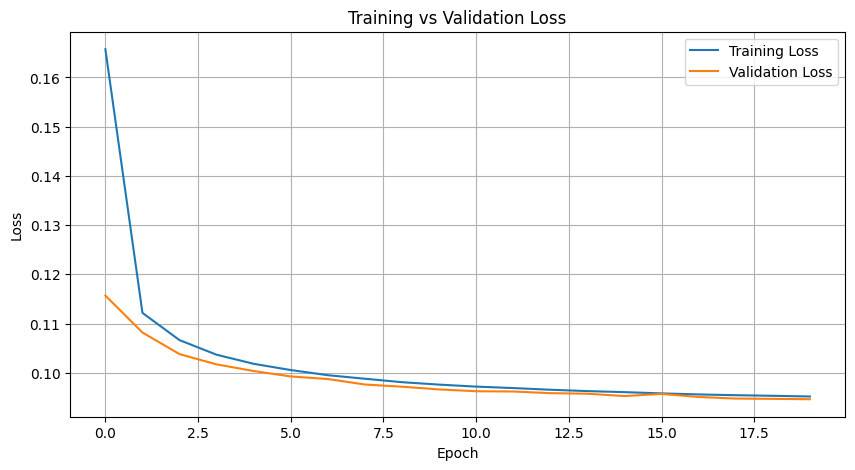

In [22]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.grid(True)

plt.savefig("/kaggle/working/outputs/loss_curve.png")

plt.show()

In [23]:
import os

print("Model Saved:",
      os.path.exists("/kaggle/working/models/mnist_autoencoder.keras"))

Model Saved: True


In [24]:
# Generate denoised images
decoded_imgs = autoencoder.predict(x_test_noisy)

print(decoded_imgs.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 28, 28, 1)


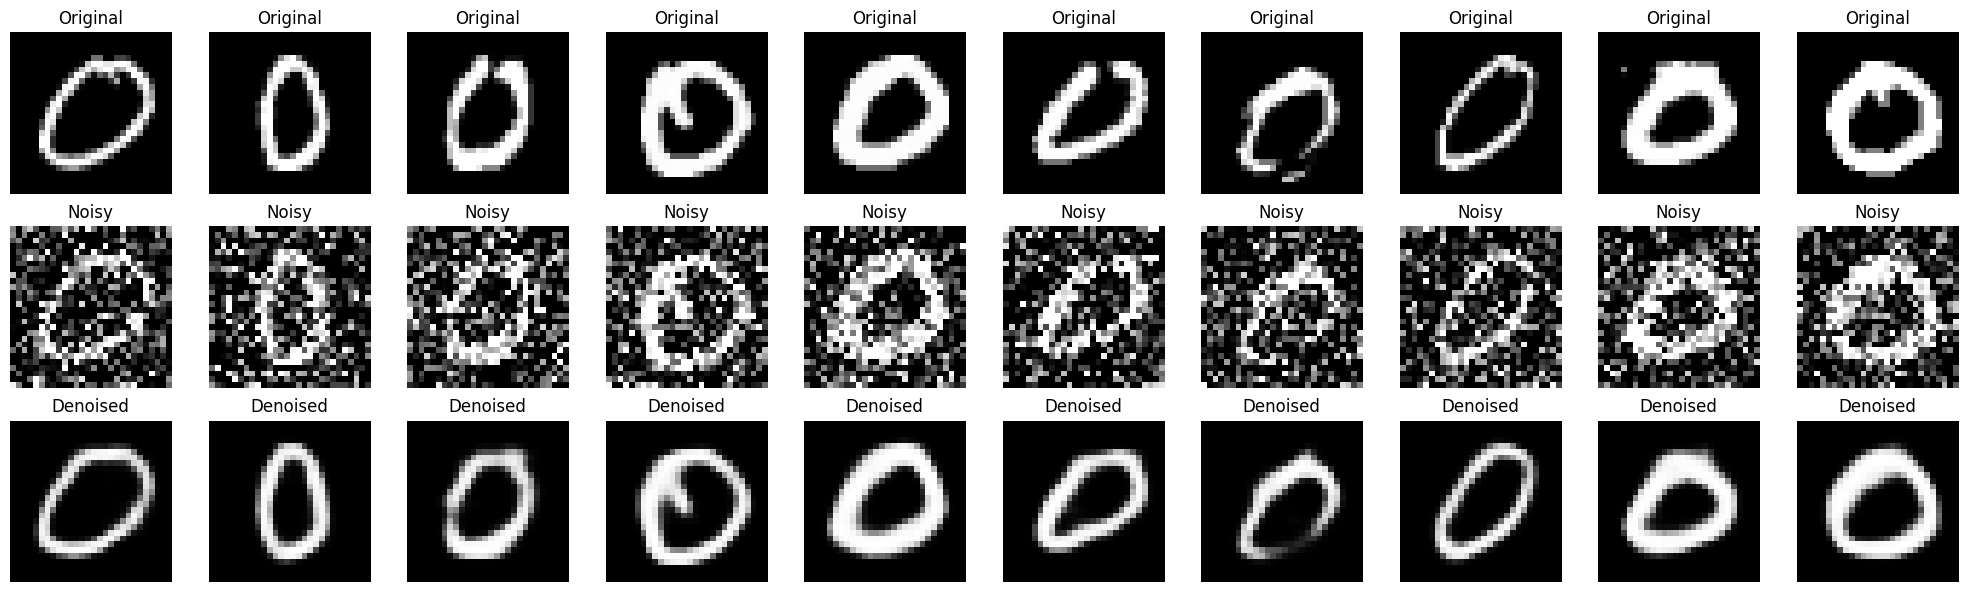

In [25]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Original Image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Image
    plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

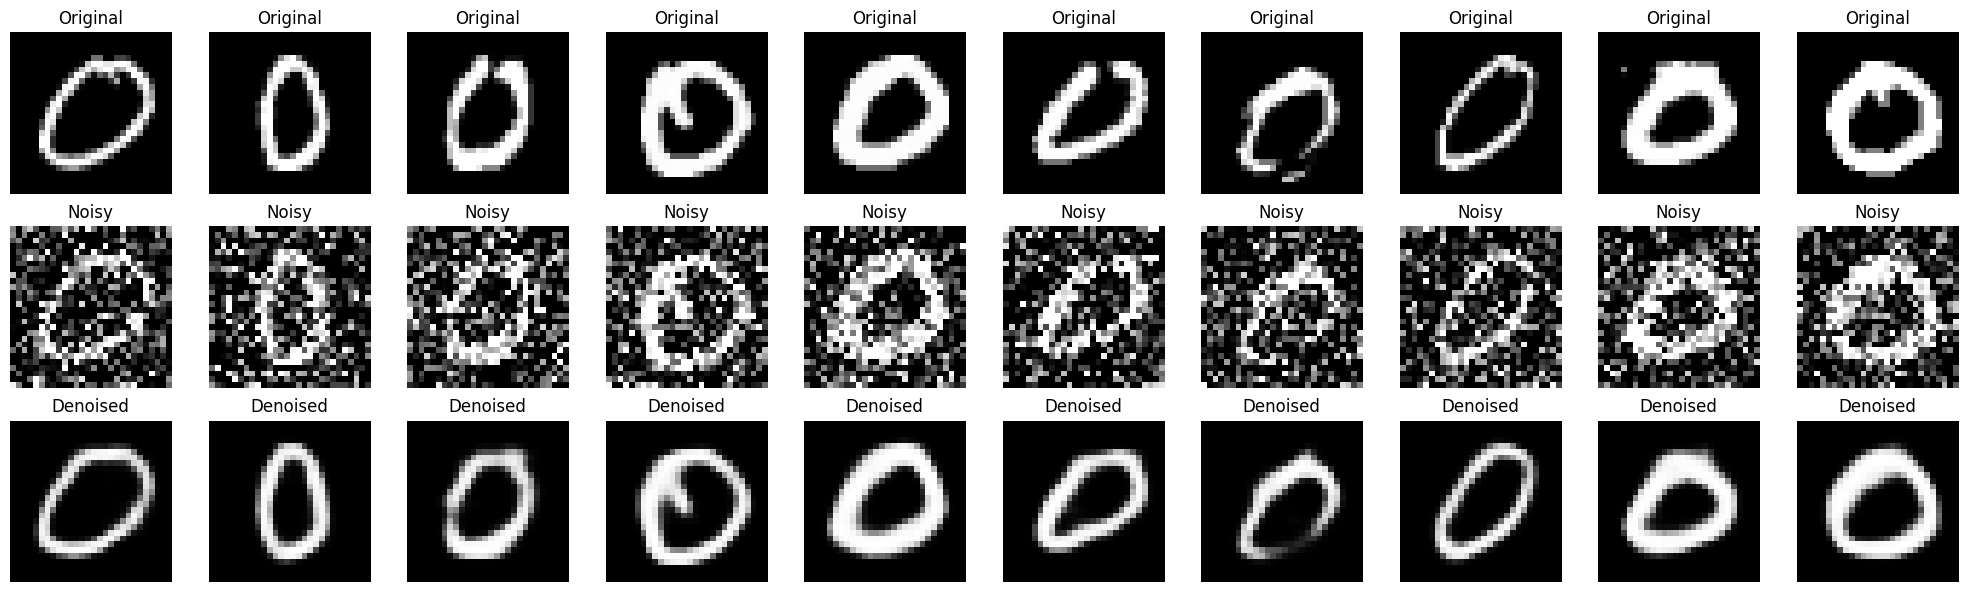

In [26]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/outputs/comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
plt.imsave(
    "/kaggle/working/outputs/noisy.png",
    x_test_noisy[0].reshape(28,28),
    cmap="gray"
)

plt.imsave(
    "/kaggle/working/outputs/denoised.png",
    decoded_imgs[0].reshape(28,28),
    cmap="gray"
)

plt.imsave(
    "/kaggle/working/outputs/original.png",
    x_test[0].reshape(28,28),
    cmap="gray"
)

print("Images saved successfully!")

Images saved successfully!


In [28]:
import shutil

shutil.make_archive(
    "/kaggle/working/MNIST_Autoencoder",
    "zip",
    "/kaggle/working"
)

'/kaggle/working/MNIST_Autoencoder.zip'